In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
! ls drive/MyDrive/plasmidgpt-v2-data/

motif_registry.json	output	 train			    val
motif_registry.parquet	outputs  training_pairs_v4.parquet  vocab.json


In [12]:
%%capture
! pip install transformers>=5.2.0
! pip install parasail 
! pip install Biopython

# Creating Scoring Metrics

In [27]:
import pandas as pd
import numpy as np
import parasail

motifs = pd.read_parquet("drive/MyDrive/plasmidgpt-v2-data/motif_registry.parquet")

motifs.head()

,uuid,token,category,features,plasmid_count,sseqid,db_source,seq_type,seq_len,sequence
0,d053544e-a84d-5811-8181-c761bd39e531,<AMR_AMPICILLIN>,AMR,"AmpR,ampR",99829,AmpR,snapgene,dna,861.0,ATGAGTATTCAACATTTCCGTGTCGCCCTTATTCCCTTTTTTGCGG...
1,d053544e-a84d-5811-8181-c761bd39e531,<AMR_AMPICILLIN>,AMR,"AmpR,ampR",99829,AmpR_(2),snapgene,dna,861.0,ATGAGTATTCAACATTTCCGTGTCGCCCTTATTCCCTTTTTTGCGG...
2,d053544e-a84d-5811-8181-c761bd39e531,<AMR_AMPICILLIN>,AMR,"AmpR,ampR",99829,AmpR_(3),snapgene,dna,861.0,ATGAGCATCCAACATTTTCGTGTCGCACTCATTCCCTTCTTTGCGG...
3,d053544e-a84d-5811-8181-c761bd39e531,<AMR_AMPICILLIN>,AMR,"AmpR,ampR",99829,AmpR_(4),snapgene,dna,861.0,ATGAGTATTCAACATTTCCGTGTCGCCCTTATTCCCTTTTTTGCGG...
4,d053544e-a84d-5811-8181-c761bd39e531,<AMR_AMPICILLIN>,AMR,"AmpR,ampR",99829,P12529,swissprot,protein,291.0,MTRSYIPLNSLRAFEAAARHLSFTRAAIELNVTHSAISQHVKSLEQ...


In [50]:
import parasail
from Bio.Seq import Seq
import re

## Motif-Based Sequence Scoring

### What this does

We evaluate generated plasmid sequences by aligning expected functional annotations (promoters, origins of replication, resistance genes, etc.) against the generated DNA using semi-global sequence alignment via [parasail](https://github.com/jeffdaily/parasail).

For each expected annotation token (e.g. `<PROM_AMPR>`, `<ORI_COLE1>`), the scorer:

1. Looks up all reference sequences for that token in our motif database (which contains both DNA and protein references from SnapGene, SwissProt, etc.)
2. Aligns each reference against the target plasmid using `sg_qx` semi-global alignment (query end-gaps free, reference end-gaps penalized) — this finds the motif anywhere within the target without letting the aligner skip parts of the motif
3. Parses the CIGAR string to extract true match/mismatch/gap counts and genomic coordinates
4. Deduplicates hits: first within each token (multiple DB variants), then across tokens (different annotations claiming the same region), using greedy NMS with IoU-based overlap detection
5. Computes a per-token quality score: `0.4 × pct_identity + 0.35 × coverage + 0.25 × norm_score`
6. Aggregates into a composite: `composite = quality × recall_penalty`, where quality is the geometric mean of found token scores raised to a sharpness exponent, and recall_penalty is a soft linear term that doesn't destroy the score when DB references are missing

### Composite score formula
```
quality       = geo_mean(found_token_scores) ^ sharpness
recall_penalty = recall_floor + (1 - recall_floor) × (found / expected)
composite      = quality × recall_penalty
```

Default parameters: `sharpness=2.0`, `recall_floor=0.5`, `norm_score_cap=5.0`.


In [217]:
import parasail
from Bio.Seq import Seq
import re
from collections import defaultdict


class MotifScorer:
    def __init__(self, target_dna, dna_gap_open=5, dna_gap_extend=2,
                 prot_gap_open=11, prot_gap_extend=1):
        self.target_dna = self._clean_seq(target_dna)
        self.target_len = len(self.target_dna)
        self.dna_gap_open = dna_gap_open
        self.dna_gap_extend = dna_gap_extend
        self.prot_gap_open = prot_gap_open
        self.prot_gap_extend = prot_gap_extend

        self.protein_frames = self._get_six_frames(self.target_dna)

    @staticmethod
    def _clean_seq(seq):
        lines = seq.strip().split('\n')
        lines = [l for l in lines if not l.startswith('>')]
        cleaned = ''.join(lines).upper()
        cleaned = re.sub(r'[^ATGCNRYSWKMBDHV]', '', cleaned)
        return cleaned

    def _get_six_frames(self, dna):
        s = Seq(dna)
        frames = []
        for i in range(3):
            f_seq = s[i:]
            f_seq = f_seq[:len(f_seq) - (len(f_seq) % 3)]
            frames.append(str(f_seq.translate(stop_symbol="X")))

            r_seq = s.reverse_complement()[i:]
            r_seq = r_seq[:len(r_seq) - (len(r_seq) % 3)]
            frames.append(str(r_seq.translate(stop_symbol="X")))
        return frames

    # ── CIGAR parsing ──────────────────────────────────────────────

    @staticmethod
    def _parse_cigar(cigar_str):
        """Parse CIGAR string, stripping leading/trailing insertions (query end-gaps).
        
        Returns dict with:
            matches, mismatches: from = and X ops in the core alignment
            ins:   internal insertions only (extra target bases within the alignment)
            dels:  deletions (motif bases missing from target)
            core_len:  matches + mismatches (aligned columns, no gaps)
            start_query, end_query: target coordinates of the aligned region
            ref_consumed: motif bases consumed in the core alignment
        """
        ops = re.findall(r'(\d+)([MIDX=])', cigar_str)

        # Strip leading and trailing I ops (query end-gaps from sg_qx)
        while ops and ops[0][1] == 'I':
            ops.pop(0)
        while ops and ops[-1][1] == 'I':
            ops.pop()

        # Re-count leading I to get correct query start offset
        all_ops = re.findall(r'(\d+)([MIDX=])', cigar_str)
        leading_i = 0
        for length_str, op in all_ops:
            if op == 'I':
                leading_i += int(length_str)
            else:
                break

        matches = 0
        mismatches = 0
        ins = 0
        dels = 0
        query_pos = leading_i
        ref_pos = 0
        start_query = None
        end_query = None

        for length_str, op in ops:
            length = int(length_str)
            if op in ('=', 'M'):
                if start_query is None:
                    start_query = query_pos
                end_query = query_pos + length - 1
                matches += length
                query_pos += length
                ref_pos += length
            elif op == 'X':
                if start_query is None:
                    start_query = query_pos
                end_query = query_pos + length - 1
                mismatches += length
                query_pos += length
                ref_pos += length
            elif op == 'I':
                ins += length
                query_pos += length
            elif op == 'D':
                dels += length
                ref_pos += length

        return {
            "matches": matches,
            "mismatches": mismatches,
            "ins": ins,
            "dels": dels,
            "core_len": matches + mismatches,
            "start_query": start_query if start_query is not None else 0,
            "end_query": end_query if end_query is not None else 0,
            "ref_consumed": ref_pos,
        }

    # ── Alignment ──────────────────────────────────────────────────

    def _align_dna(self, motif_seq):
        res = parasail.sg_qx_trace_striped_sat(
            self.target_dna, motif_seq,
            self.dna_gap_open, self.dna_gap_extend,
            parasail.dnafull
        )
        cigar_str = res.cigar.decode.decode()
        parsed = self._parse_cigar(cigar_str)
        return self._build_hit(res.score, parsed, len(motif_seq), seq_type="dna")

    def _align_protein(self, motif_seq):
        best_hit = None

        for idx, frame_seq in enumerate(self.protein_frames):
            if not frame_seq:
                continue
            res = parasail.sg_qx_trace_striped_sat(
                frame_seq, motif_seq,
                self.prot_gap_open, self.prot_gap_extend,
                parasail.blosum62
            )
            cigar_str = res.cigar.decode.decode()
            parsed = self._parse_cigar(cigar_str)
            hit = self._build_hit(res.score, parsed, len(motif_seq),
                                  seq_type="protein", frame=idx)

            # Map protein coords → DNA coords for cross-type dedup
            is_reverse = (idx % 2 == 1)
            frame_offset = idx // 2
            dna_start = hit["start_pos"] * 3 + frame_offset
            dna_end = (hit["end_pos"] + 1) * 3 - 1 + frame_offset
            if is_reverse:
                dna_start_tmp = self.target_len - 1 - dna_end
                dna_end = self.target_len - 1 - (hit["start_pos"] * 3 + frame_offset)
                dna_start = dna_start_tmp
            hit["dna_start"] = dna_start
            hit["dna_end"] = dna_end

            if best_hit is None or hit["score"] > best_hit["score"]:
                best_hit = hit

        return best_hit

    def _build_hit(self, score, parsed, motif_len, seq_type="dna", frame=None):
        core = parsed["core_len"]
        pct_id = (parsed["matches"] / core * 100) if core > 0 else 0.0
        # coverage = fraction of motif bases that aligned (not gapped)
        coverage = (parsed["matches"] / motif_len * 100) if motif_len > 0 else 0.0
        norm_score = score / motif_len if motif_len > 0 else 0.0

        hit = {
            "score": score,
            "norm_score": round(norm_score, 2),
            "pct_id": round(pct_id, 2),
            "coverage": round(coverage, 2),
            "matches": parsed["matches"],
            "mismatches": parsed["mismatches"],
            "internal_gaps": parsed["ins"] + parsed["dels"],
            "alignment_len": core,
            "start_pos": parsed["start_query"],
            "end_pos": parsed["end_query"],
            "seq_type": seq_type,
        }
        if frame is not None:
            hit["protein_frame"] = frame
        return hit

    # ── Public API ─────────────────────────────────────────────────

    @staticmethod
    def _min_pct_id_for_length(motif_len, base_min_pct_id=85.0):
        """Length-adaptive identity threshold.
        
        Short motifs match random DNA at high identity by chance,
        so they need stricter cutoffs. Long motifs can tolerate more
        mismatches because chance matches are exponentially less likely.
        
        Uses an exponential decay curve:
            threshold = base + 15 * exp(-motif_len / 100)
        
        Examples:
            30bp  → ~96% required
            50bp  → ~94% required
            100bp → ~91% required
            300bp → ~86% required
            800bp → ~85% required (≈ base)
        """
        import math
        penalty = 15.0 * math.exp(-motif_len / 100.0)
        return min(base_min_pct_id + penalty, 99.0)

    def run_tokens(self, tokens_to_search, motif_db, min_pct_id=85.0,
                   min_norm_score=0.0, min_coverage=50.0,
                   adaptive_id=True):
        """Score motifs and return best hits per token, deduped by location.
        
        Args:
            tokens_to_search: list of token strings
            motif_db: list of dicts or pandas DataFrame
            min_pct_id: base minimum percent identity (default 85).
                        If adaptive_id=True, actual threshold is higher for
                        short motifs (see _min_pct_id_for_length).
            min_norm_score: minimum normalised score to keep (default 0)
            min_coverage: minimum coverage (matches/motif_len %) to keep (default 50)
            adaptive_id: if True, use length-adaptive identity threshold (default True)
        """
        try:
            import pandas as pd
            if isinstance(motif_db, pd.DataFrame):
                motif_db = motif_db.to_dict('records')
        except ImportError:
            pass

        token_set = set(tokens_to_search)
        sub_db = [m for m in motif_db if m['token'] in token_set]

        token_hits = defaultdict(list)

        for entry in sub_db:
            motif_seq = entry.get('sequence')
            if not motif_seq:
                continue  # skip None or empty sequences

            is_protein = (entry.get('seq_type') or 'dna').lower() == 'protein'

            # Clean motif sequence (strip headers, whitespace, non-DNA chars)
            if not is_protein:
                motif_seq = self._clean_seq(motif_seq)
            else:
                # For protein: strip whitespace and uppercase
                motif_seq = re.sub(r'\s+', '', motif_seq).upper()

            if len(motif_seq) < 10:
                continue  # skip degenerate motifs

            if is_protein:
                hit = self._align_protein(motif_seq)
            else:
                hit = self._align_dna(motif_seq)

            # Guard against None (e.g. protein with no valid frames)
            if hit is None:
                continue

            # Length-adaptive identity threshold
            if adaptive_id:
                effective_min_id = self._min_pct_id_for_length(
                    len(motif_seq), base_min_pct_id=min_pct_id
                )
            else:
                effective_min_id = min_pct_id

            # Quality filter
            if (hit["pct_id"] < effective_min_id 
                or hit["norm_score"] < min_norm_score
                or hit["coverage"] < min_coverage):
                continue

            hit["token"] = entry.get('token')
            hit["db_entry"] = entry.get('sseqid', entry.get('features', ''))
            hit["motif_len"] = len(motif_seq)

            if not is_protein:
                hit["dna_start"] = hit["start_pos"]
                hit["dna_end"] = hit["end_pos"]

            token_hits[hit["token"]].append(hit)

        # Phase 1: per-token dedup (collapse DB variants within same token)
        per_token = []
        for token in tokens_to_search:
            hits = token_hits.get(token, [])
            if not hits:
                continue
            deduped = self._dedup_hits(hits)
            per_token.extend(deduped)

        # Phase 2: cross-token dedup (different tokens claiming same region)
        results = self._dedup_hits_global(per_token)

        return results

    @staticmethod
    def _dedup_hits(hits, overlap_frac=0.5):
        """Greedy NMS: keep best non-overlapping hits for a single token."""
        ranked = sorted(hits, key=lambda h: h["score"], reverse=True)
        kept = []

        for hit in ranked:
            h_start = hit.get("dna_start", 0)
            h_end = hit.get("dna_end", 0)
            h_span = max(h_end - h_start + 1, 1)

            dominated = False
            for k in kept:
                k_start = k.get("dna_start", 0)
                k_end = k.get("dna_end", 0)
                overlap = max(0, min(h_end, k_end) - max(h_start, k_start) + 1)
                if overlap / h_span >= overlap_frac:
                    dominated = True
                    break

            if not dominated:
                kept.append(hit)

        return kept

    @staticmethod
    def _dedup_hits_global(hits, iou_threshold=0.3):
        """Cross-token NMS: when different tokens claim the same region,
        keep the hit with higher norm_score.
        
        Uses IoU (intersection over union) so a short promoter (100bp) 
        overlapping slightly with a long ori (600bp) won't suppress either.
        Only truly redundant annotations (high IoU) get deduplicated.
        """
        ranked = sorted(hits, key=lambda h: h.get("norm_score", 0), reverse=True)
        kept = []

        for hit in ranked:
            h_start = hit.get("dna_start", 0)
            h_end = hit.get("dna_end", 0)
            h_span = max(h_end - h_start + 1, 1)

            dominated = False
            for k in kept:
                k_start = k.get("dna_start", 0)
                k_end = k.get("dna_end", 0)
                k_span = max(k_end - k_start + 1, 1)

                overlap = max(0, min(h_end, k_end) - max(h_start, k_start) + 1)
                union = h_span + k_span - overlap
                iou = overlap / union if union > 0 else 0

                if iou >= iou_threshold:
                    dominated = True
                    break

            if not dominated:
                kept.append(hit)

        return kept

    # ── Composite scoring ──────────────────────────────────────────

    def score(self, expected_tokens, motif_db, 
              w_id=0.4, w_cov=0.35, w_norm=0.25,
              norm_score_cap=5.0, 
              sharpness=2.0,
              recall_floor=0.5,
              **run_kwargs):
        """Compute a composite score for how well a plasmid matches expected annotations.
        
        Separates quality (how good are the hits we found?) from recall 
        (how many expected tokens did we find?). Sharpness only amplifies
        quality differences, so missing DB references don't crater the score.
        
        Formula:
            quality    = geo_mean(found_token_scores) ^ sharpness
            recall_pen = recall_floor + (1 - recall_floor) * recall
            composite  = quality * recall_pen
        
        This means:
        - Mutations degrade quality → composite drops steeply (sharpness=2)
        - Missing DB refs reduce recall_pen gently (0.5 + 0.5*recall)
        - All tokens found, perfect quality → composite ≈ 1.0
        - All tokens found, corrupted → composite drops to ~0.25
        - 3/5 tokens found, good quality → composite ≈ 0.65 (not zero)
        
        Args:
            expected_tokens: list of token strings expected in this plasmid
            motif_db: list of dicts or DataFrame (passed to run_tokens)
            w_id: weight for percent identity (default 0.4)
            w_cov: weight for coverage (default 0.35)
            w_norm: weight for normalised score (default 0.25)
            norm_score_cap: cap for norm_score scaling (default 5.0)
            sharpness: exponent on quality geo_mean (default 2.0).
                       Controls separation between good and bad sequences.
            recall_floor: minimum recall penalty (default 0.5).
                          At recall=0, composite = quality * recall_floor.
                          Higher = more forgiving of missing annotations.
            **run_kwargs: forwarded to run_tokens (min_pct_id, min_coverage, etc.)
        
        Returns:
            dict with:
                composite: float 0-1, final score (quality * recall_penalty)
                quality: float 0-1, geo_mean of found tokens ^ sharpness
                geo_mean: float 0-1, raw geometric mean of found token scores
                recall: float 0-1, found/expected
                recall_penalty: float, the recall multiplier applied
                token_scores: dict of token → {score, pct_id, coverage, ...}
                found: int, number of tokens with a hit
                expected: int, total expected tokens
                hits: list of all raw hits from run_tokens
        """
        import math

        hits = self.run_tokens(expected_tokens, motif_db, **run_kwargs)

        # Best hit per token (by norm_score)
        best_per_token = {}
        for hit in hits:
            tok = hit["token"]
            if tok not in best_per_token or hit["norm_score"] > best_per_token[tok]["norm_score"]:
                best_per_token[tok] = hit

        token_scores = {}
        found_scores = []

        for tok in expected_tokens:
            if tok in best_per_token:
                h = best_per_token[tok]
                id_score = h["pct_id"] / 100.0
                cov_score = h["coverage"] / 100.0
                norm_scaled = min(h["norm_score"] / norm_score_cap, 1.0)

                quality = (w_id * id_score 
                         + w_cov * cov_score 
                         + w_norm * norm_scaled)

                token_scores[tok] = {
                    "score": round(quality, 4),
                    "found": True,
                    "pct_id": h["pct_id"],
                    "coverage": h["coverage"],
                    "norm_score": h["norm_score"],
                    "db_entry": h.get("db_entry", ""),
                    "dna_start": h.get("dna_start"),
                    "dna_end": h.get("dna_end"),
                }
                found_scores.append(quality)
            else:
                token_scores[tok] = {
                    "score": 0.0,
                    "found": False,
                    "pct_id": 0,
                    "coverage": 0,
                    "norm_score": 0,
                    "db_entry": None,
                    "dna_start": None,
                    "dna_end": None,
                }

        n_expected = len(expected_tokens)
        n_found = len(found_scores)
        recall = n_found / n_expected if n_expected > 0 else 0.0

        # Quality: geo mean of found tokens only, raised to sharpness
        if found_scores:
            log_scores = [math.log(max(s, 1e-6)) for s in found_scores]
            geo_mean = math.exp(sum(log_scores) / len(log_scores))
            quality = geo_mean ** sharpness
        else:
            geo_mean = 0.0
            quality = 0.0

        # Recall penalty: soft linear from recall_floor to 1.0
        recall_penalty = recall_floor + (1.0 - recall_floor) * recall

        composite = quality * recall_penalty

        return {
            "composite": round(composite, 4),
            "quality": round(quality, 4),
            "geo_mean": round(geo_mean, 4),
            "recall": round(recall, 4),
            "recall_penalty": round(recall_penalty, 4),
            "found": n_found,
            "expected": n_expected,
            "token_scores": token_scores,
            "hits": hits,
        }

In [218]:
pUC19 = """GAGATACCTACAGCGTGAGCTATGAGAAAGCGCCACGCTTCCCGAAGGGAGAAAGGCGGACAGGTATCCGGTAAGCGGCAGGGTCGGAACAGGAGAGCGCACGAGGGAGCTTCCAGGGGGAAACGCCTGGTATCTT
TATAGTCCTGTCGGGTTTCGCCACCTCTGACTTGAGCGTCGATTTTTGTGATGCTCGTCAGGGGGGCGGAGCCTATGGAAAAACGCCAGCAACGCGGCCTTTTTACGGTTCCTGGCCTTTTGCTGGCCTTTTGCTCACATGTTCTTT
CCTGCGTTATCCCCTGATTCTGTGGATAACCGTATTACCGCCTTTGAGTGAGCTGATACCGCTCGCCGCAGCCGAACGACCGAGCGCAGCGAGTCAGTGAGCGAGGAAGCGGAAGAGCGCCCAATACGCAAACCGCCTCTCCCCGCG
CGTTGGCCGATTCATTAATGCAGCTGGCACGACAGGTTTCCCGACTGGAAAGCGGGCAGTGAGCGCAACGCAATTAATGTGAGTTAGCTCACTCATTAGGCACCCCAGGCTTTACACTTTATGCTTCCGGCTCGTATGTTGTGTGGA
ATTGTGAGCGGATAACAATTTCACACAGGAAACAGCTATGACCATGATTACGCCAAGCTTGCATGCCTGCAGGTCGACTCTAGAGGATCCCCGGGTACCGAGCTCGAATTCACTGGCCGTCGTTTTACAACGTCGTGACTGGGAAAA
CCCTGGCGTTACCCAACTTAATCGCCTTGCAGCACATCCCCCTTTCGCCAGCTGGCGTAATAGCGAAGAGGCCCGCACCGATCGCCCTTCCCAACAGTTGCGCAGCCTGAATGGCGAATGGCGCCTGATGCGGTATTTTCTCCTTAC
GCATCTGTGCGGTATTTCACACCGCATATGGTGCACTCTCAGTACAATCTGCTCTGATGCCGCATAGTTAAGCCAGCCCCGACACCCGCCAACACCCGCTGACGCGCCCTGACGGGCTTGTCTGCTCCCGGCATCCGCTTACAGACA
AGCTGTGACCGTCTCCGGGAGCTGCATGTGTCAGAGGTTTTCACCGTCATCACCGAAACGCGCGAGACGAAAGGGCCTCGTGATACGCCTATTTTTATAGGTTAATGTCATGATAATAATGGTTTCTTAGACGTCAGGTGGCACTTT
TCGGGGAAATGTGCGCGGAACCCCTATTTGTTTATTTTTCTAAATACATTCAAATATGTATCCGCTCATGAGACAATAACCCTGATAAATGCTTCAATAATATTGAAAAAGGAAGAGTATGAGTATTCAACATTTCCGTGTCGCCCT
TATTCCCTTTTTTGCGGCATTTTGCCTTCCTGTTTTTGCTCACCCAGAAACGCTGGTGAAAGTAAAAGATGCTGAAGATCAGTTGGGTGCACGAGTGGGTTACATCGAACTGGATCTCAACAGCGGTAAGATCCTTGAGAGTTTTCG
CCCCGAAGAACGTTTTCCAATGATGAGCACTTTTAAAGTTCTGCTATGTGGCGCGGTATTATCCCGTATTGACGCCGGGCAAGAGCAACTCGGTCGCCGCATACACTATTCTCAGAATGACTTGGTTGAGTACTCACCAGTCACAGA
AAAGCATCTTACGGATGGCATGACAGTAAGAGAATTATGCAGTGCTGCCATAACCATGAGTGATAACACTGCGGCCAACTTACTTCTGACAACGATCGGAGGACCGAAGGAGCTAACCGCTTTTTTGCACAACATGGGGGATCATGT
AACTCGCCTTGATCGTTGGGAACCGGAGCTGAATGAAGCCATACCAAACGACGAGCGTGACACCACGATGCCTGTAGCAATGGCAACAACGTTGCGCAAACTATTAACTGGCGAACTACTTACTCTAGCTTCCCGGCAACAATTAAT
AGACTGGATGGAGGCGGATAAAGTTGCAGGACCACTTCTGCGCTCGGCCCTTCCGGCTGGCTGGTTTATTGCTGATAAATCTGGAGCCGGTGAGCGTGGGTCTCGCGGTATCATTGCAGCACTGGGGCCAGATGGTAAGCCCTCCCG
TATCGTAGTTATCTACACGACGGGGAGTCAGGCAACTATGGATGAACGAAATAGACAGATCGCTGAGATAGGTGCCTCACTGATTAAGCATTGGTAACTGTCAGACCAAGTTTACTCATATATACTTTAGATTGATTTAAAACTTCA
TTTTTAATTTAAAAGGATCTAGGTGAAGATCCTTTTTGATAATCTCATGACCAAAATCCCTTAACGTGAGTTTTCGTTCCACTGAGCGTCAGACCCCGTAGAAAAGATCAAAGGATCTTCTTGAGATCCTTTTTTTCTGCGCGTAAT
CTGCTGCTTGCAAACAAAAAAACCACCGCTACCAGCGGTGGTTTGTTTGCCGGATCAAGAGCTACCAACTCTTTTTCCGAAGGTAACTGGCTTCAGCAGAGCGCAGATACCAAATACTGTTCTTCTAGTGTAGCCGTAGTTAGGCCA
CCACTTCAAGAACTCTGTAGCACCGCCTACATACCTCGCTCTGCTAATCCTGTTACCAGTGGCTGCTGCCAGTGGCGATAAGTCGTGTCTTACCGGGTTGGACTCAAGACGATAGTTACCGGATAAGGCGCAGCGGTCGGGCTGAAC
GGGGGGTTCGTGCACACAGCCCAGCTTGGAGCGAACGACCTACACCGAACT""" 

In [219]:
import random


def corrupt_plasmid(seq, n_sub=0, n_ins=0, n_del=0, max_ins_len=15, seed=None):
    """Apply controlled mutations to a DNA sequence.
    
    Args:
        n_sub: number of point substitutions
        n_ins: number of random insertions (1 to max_ins_len bp each)
        n_del: number of single-base deletions
    """
    if seed is not None:
        random.seed(seed)
    bases = list(seq.replace('\n', '').replace(' ', ''))
    
    # Substitutions
    for _ in range(n_sub):
        pos = random.randint(0, len(bases) - 1)
        bases[pos] = random.choice([b for b in "ATGC" if b != bases[pos]])
    
    # Deletions (do before insertions so positions don't shift)
    for _ in range(n_del):
        if len(bases) > 100:
            pos = random.randint(0, len(bases) - 1)
            bases.pop(pos)
    
    # Insertions
    for _ in range(n_ins):
        pos = random.randint(0, len(bases))
        insert = ''.join(random.choice("ATGC") for _ in range(random.randint(1, max_ins_len)))
        bases[pos:pos] = list(insert)
    
    return ''.join(bases)



In [220]:
#get tokens for pUC19 (expected tokens)
expected_tokens = motifs[motifs.sseqid.isin(["AmpR_promoter_(4)", "AmpR_(2)", "ori", "MCS_(8)", "lac_promoter", "CAP_binding_site", "lac_operator_(2)", "lacZ_alpha", "bom", "lacI", "rop"])].token.tolist()
expected_tokens

['<AMR_AMPICILLIN>', '<ELEM_MCS>', '<ORI_COLE1>', '<PROM_AMPR>', '<PROM_LAC>']

In [221]:
%%timeit
puc19_scorer = MotifScorer(pUC19)
result = puc19_scorer.score(
    expected_tokens=['<AMR_AMPICILLIN>', '<ELEM_MCS>', '<ORI_COLE1>', '<PROM_AMPR>', '<PROM_LAC>'],
    motif_db=motifs,  
)

47.8 ms ± 268 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [222]:
puc19_scorer = MotifScorer(pUC19)
token_matches = puc19_scorer.run_tokens(expected_tokens, motifs)
for x in token_matches:
    print(x)

print("="*100)

result = puc19_scorer.score(
    expected_tokens=['<AMR_AMPICILLIN>', '<ELEM_MCS>', '<ORI_COLE1>', '<PROM_AMPR>', '<PROM_LAC>'],
    motif_db=motifs,  # your DataFrame
)
print(result["composite"])  # 0.89 for real pUC19
print(result["recall"]) 

{'score': 525, 'norm_score': 5.0, 'pct_id': 100.0, 'coverage': 100.0, 'matches': 105, 'mismatches': 0, 'internal_gaps': 0, 'alignment_len': 105, 'start_pos': 1178, 'end_pos': 1282, 'seq_type': 'dna', 'token': '<PROM_AMPR>', 'db_entry': 'AmpR_promoter_(4)', 'motif_len': 105, 'dna_start': 1178, 'dna_end': 1282}
{'score': 155, 'norm_score': 5.0, 'pct_id': 100.0, 'coverage': 100.0, 'matches': 31, 'mismatches': 0, 'internal_gaps': 0, 'alignment_len': 31, 'start_pos': 540, 'end_pos': 570, 'seq_type': 'dna', 'token': '<PROM_LAC>', 'db_entry': 'lac_promoter', 'motif_len': 31, 'dna_start': 540, 'dna_end': 570}
{'score': 4287, 'norm_score': 4.98, 'pct_id': 99.77, 'coverage': 99.77, 'matches': 859, 'mismatches': 2, 'internal_gaps': 0, 'alignment_len': 861, 'start_pos': 1283, 'end_pos': 2143, 'seq_type': 'dna', 'token': '<AMR_AMPICILLIN>', 'db_entry': 'AmpR_(2)', 'motif_len': 861, 'dna_start': 1283, 'dna_end': 2143}
{'score': 1414, 'norm_score': 2.4, 'pct_id': 99.73, 'coverage': 62.99, 'matches': 

In [223]:
expected = ['<AMR_AMPICILLIN>', '<ELEM_MCS>', '<ORI_COLE1>', '<PROM_AMPR>', '<PROM_LAC>']

for n_mut in [0, 10, 50, 100, 200, 500]:
    corrupted = corrupt_plasmid(pUC19, n_sub=n_mut, n_ins=n_mut//5, n_del=n_mut//5, seed=42)
    scorer = MotifScorer(corrupted)
    result = scorer.score(expected, motifs, sharpness=3.0)
    print(f"mutations={n_mut:4d}  composite={result['composite']:.4f}  recall={result['recall']}")

mutations=   0  composite=0.7162  recall=0.8
mutations=  10  composite=0.7115  recall=0.8
mutations=  50  composite=0.6748  recall=0.8
mutations= 100  composite=0.6258  recall=0.8
mutations= 200  composite=0.5859  recall=0.8
mutations= 500  composite=0.3624  recall=0.6


In [224]:
for s in [2.0, 3.0, 4.0, 5.0, 6.0, 7.0]:
    print(f"\n=== sharpness={s} ===")
    for n_mut in [0, 10, 50, 100, 200, 500]:
        corrupted = corrupt_plasmid(pUC19, n_sub=n_mut, n_ins=n_mut//5, n_del=n_mut//5, seed=42)
        scorer = MotifScorer(corrupted)
        result = scorer.score(expected, motifs, sharpness=s)
        print(f"  mut={n_mut:4d}  composite={result['composite']:.4f}")


=== sharpness=2.0 ===
  mut=   0  composite=0.7728
  mut=  10  composite=0.7695
  mut=  50  composite=0.7428
  mut= 100  composite=0.7064
  mut= 200  composite=0.6761
  mut= 500  composite=0.4719

=== sharpness=3.0 ===
  mut=   0  composite=0.7162
  mut=  10  composite=0.7115
  mut=  50  composite=0.6748
  mut= 100  composite=0.6258
  mut= 200  composite=0.5859
  mut= 500  composite=0.3624

=== sharpness=4.0 ===
  mut=   0  composite=0.6636
  mut=  10  composite=0.6578
  mut=  50  composite=0.6130
  mut= 100  composite=0.5544
  mut= 200  composite=0.5078
  mut= 500  composite=0.2783

=== sharpness=5.0 ===
  mut=   0  composite=0.6150
  mut=  10  composite=0.6083
  mut=  50  composite=0.5569
  mut= 100  composite=0.4911
  mut= 200  composite=0.4401
  mut= 500  composite=0.2138

=== sharpness=6.0 ===
  mut=   0  composite=0.5699
  mut=  10  composite=0.5624
  mut=  50  composite=0.5059
  mut= 100  composite=0.4351
  mut= 200  composite=0.3815
  mut= 500  composite=0.1642

=== sharpness=

# Benchmark scorer on real plasmids


In [225]:
prompt_pairs = pd.read_parquet("drive/MyDrive/plasmidgpt-v2-data/training_pairs_v4.parquet")
prompt_pairs.head()


,plasmid_id,prompt,prompt_hash,sorted_tokens,n_tokens,sequence,sequence_length,full_text,total_length,len_bucket,splits,reward_motifs
0,207031,<BOS><VEC_YEAST><SP_YEAST><COPY_HIGH><AMR_AMPI...,-2146193517,"[""<VEC_YEAST>"",""<SP_YEAST>"",""<COPY_HIGH>"",""<AM...",15,CACACAGGAAACAGCTATGACCATGATTACGCCAAGCGCGCAATTA...,11038,<BOS><VEC_YEAST><SP_YEAST><COPY_HIGH><AMR_AMPI...,11232,leq_16k,"[""combined"",""yeast""]","[{""qstart"":""2249"",""qend"":""2870"",""motif_canonic..."
1,149424,<BOS><VEC_CRISPR><VEC_INSECT><SP_SYNTHETIC><CO...,-2143235575,"[""<VEC_CRISPR>"",""<VEC_INSECT>"",""<SP_SYNTHETIC>...",13,CGTCTGTACACGAACGCGTATTAACGCAGAGTGCAAAGTATAAGAG...,13159,<BOS><VEC_CRISPR><VEC_INSECT><SP_SYNTHETIC><CO...,13338,leq_16k,"[""combined"",""crispr"",""insect""]","[{""qstart"":""9139"",""qend"":""9261"",""motif_canonic..."
2,149424,<BOS><VEC_CRISPR><VEC_INSECT><SP_SYNTHETIC><CO...,-2143235575,"[""<VEC_CRISPR>"",""<VEC_INSECT>"",""<SP_SYNTHETIC>...",13,GATCTCGGATCTGACAATGTTCAGTGCAGAGACTCGGCTACGCCTC...,13159,<BOS><VEC_CRISPR><VEC_INSECT><SP_SYNTHETIC><CO...,13338,leq_16k,"[""combined"",""crispr"",""insect""]","[{""qstart"":""9139"",""qend"":""9261"",""motif_canonic..."
3,168295,<BOS><VEC_CRISPR><VEC_INSECT><SP_SYNTHETIC><CO...,-2143235575,"[""<VEC_CRISPR>"",""<VEC_INSECT>"",""<SP_SYNTHETIC>...",13,TATCCACAGAATCAGGGGATAACGCAGGAAAGAACATGTGAGCAAA...,15588,<BOS><VEC_CRISPR><VEC_INSECT><SP_SYNTHETIC><CO...,15767,leq_16k,"[""combined"",""crispr"",""insect""]","[{""qstart"":""14137"",""qend"":""14242"",""motif_canon..."
4,168295,<BOS><VEC_CRISPR><VEC_INSECT><SP_SYNTHETIC><CO...,-2143235575,"[""<VEC_CRISPR>"",""<VEC_INSECT>"",""<SP_SYNTHETIC>...",13,CAGACAAGCCCGTCAGGGCGCGTCAGCGGGTGTTGGCGGGTGTCGG...,15602,<BOS><VEC_CRISPR><VEC_INSECT><SP_SYNTHETIC><CO...,15781,leq_16k,"[""combined"",""crispr"",""insect""]","[{""qstart"":""14137"",""qend"":""14242"",""motif_canon..."


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import random

# ── Settings ──
motif_token_set = set(motifs.token.unique())
sample = prompt_pairs[prompt_pairs.sequence.str.len() > 100].sample(100, random_state=42)

def score_row(row, corrupt_fn=None):
    """Score a single row, optionally corrupting the sequence first."""
    prompt = row.prompt
    all_tokens = prompt.replace("<BOS>", "").replace("<SEP>", "").replace("><", "> <").split()
    expected_tokens = [t for t in all_tokens if t in motif_token_set]
    if not expected_tokens:
        return None
    
    seq = corrupt_fn(row.sequence) if corrupt_fn else row.sequence
    scorer = MotifScorer(seq)
    result = scorer.score(expected_tokens, motifs, sharpness=2.0)
    return result["composite"]

# ── Score three conditions ──
real_scores = sample.apply(lambda r: score_row(r), axis=1).dropna()

mild_scores = sample.apply(
    lambda r: score_row(r, corrupt_fn=lambda s: corrupt_plasmid(s, n_sub=50, n_ins=10, n_del=10, seed=42)),
    axis=1
).dropna()

broken_scores = sample.apply(
    lambda r: score_row(r, corrupt_fn=lambda s: corrupt_plasmid(s, n_sub=500, n_ins=100, n_del=100, seed=42)),
    axis=1
).dropna()

# ── Plot ──
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True, sharex=True)
bins = np.linspace(0, 1, 25)

for ax, scores, title, color in zip(
    axes,
    [real_scores, mild_scores, broken_scores],
    ["Real plasmids", "Mild corruption\n(50 sub, 10 ins, 10 del)", "Heavy corruption\n(500 sub, 100 ins, 100 del)"],
    ["#2196F3", "#FF9800", "#F44336"],
):
    ax.hist(scores, bins=bins, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(scores.median(), color="black", linestyle="--", linewidth=1.2, label=f"median={scores.median():.3f}")
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Composite score")
    ax.legend(fontsize=9)

axes[0].set_ylabel("Count")
fig.suptitle("Motif Score Distribution: Real vs Corrupted Plasmids", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# ── Summary stats ──
print(f"{'Condition':<25s} {'Mean':>6s} {'Median':>7s} {'Std':>6s} {'Min':>6s} {'Max':>6s}")
print("-" * 60)
for name, s in [("Real", real_scores), ("Mild corruption", mild_scores), ("Heavy corruption", broken_scores)]:
    print(f"{name:<25s} {s.mean():6.3f} {s.median():7.3f} {s.std():6.3f} {s.min():6.3f} {s.max():6.3f}")

In [ ]:
mild_scores = sample.apply(
    lambda r: score_row(r, corrupt_fn=lambda s: corrupt_plasmid(
        s, 
        n_sub=int(len(s) * 0.05),  # 5% substitution rate
        n_ins=int(len(s) * 0.01), 
        n_del=int(len(s) * 0.01),
    )),
    axis=1
).dropna()

broken_scores = sample.apply(
    lambda r: score_row(r, corrupt_fn=lambda s: corrupt_plasmid(
        s, 
        n_sub=int(len(s) * 0.20),  # 20% substitution rate
        n_ins=int(len(s) * 0.05), 
        n_del=int(len(s) * 0.05),
    )),
    axis=1
).dropna()

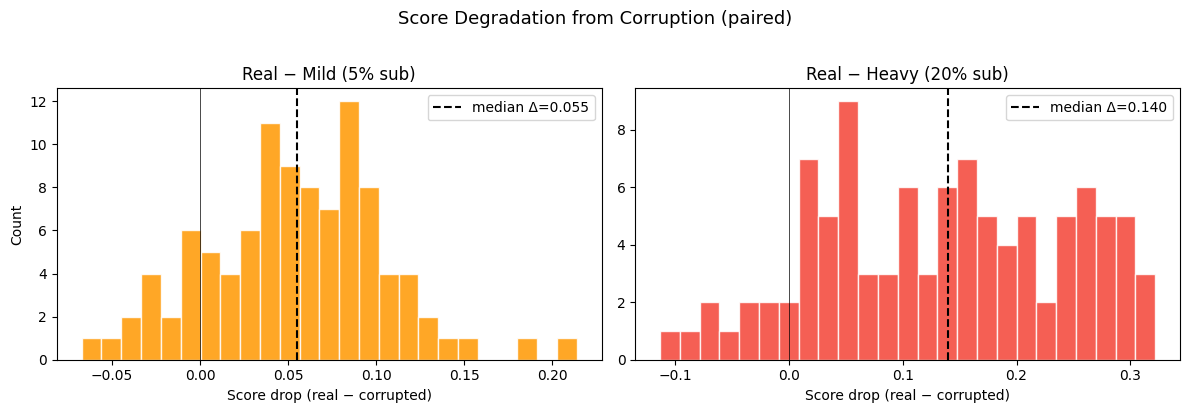

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

delta_mild = real_scores.values - mild_scores.values
delta_broken = real_scores.values - broken_scores.values

for ax, delta, title, color in zip(
    axes,
    [delta_mild, delta_broken],
    ["Real − Mild (5% sub)", "Real − Heavy (20% sub)"],
    ["#FF9800", "#F44336"],
):
    ax.hist(delta, bins=25, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(0, color="black", linestyle="-", linewidth=0.5)
    ax.axvline(np.median(delta), color="black", linestyle="--", 
               label=f"median Δ={np.median(delta):.3f}")
    ax.set_xlabel("Score drop (real − corrupted)")
    ax.set_title(title)
    ax.legend()

axes[0].set_ylabel("Count")
fig.suptitle("Score Degradation from Corruption (paired)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

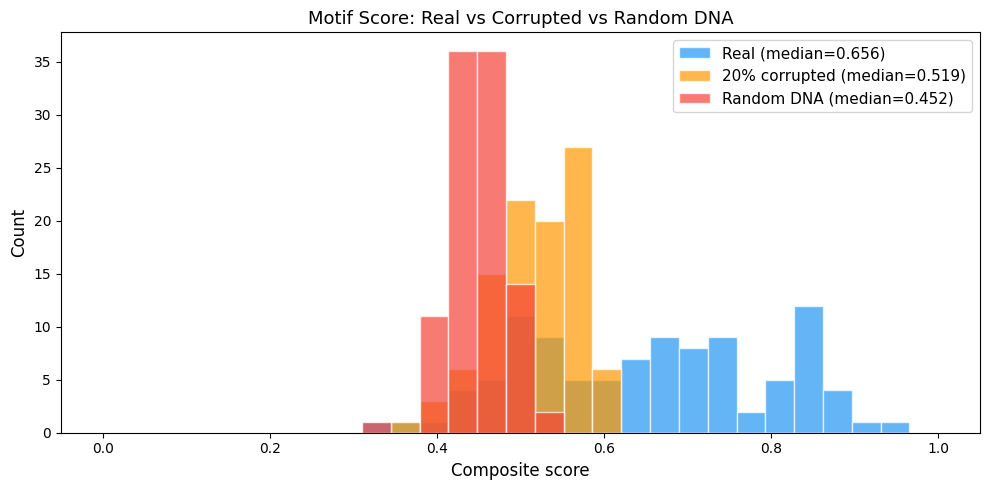


Condition                   Mean  Median    Std    Min    Max
------------------------------------------------------------
Real                       0.653   0.656  0.146  0.327  0.946
20% corrupted              0.517   0.519  0.050  0.374  0.598
Random DNA                 0.450   0.452  0.034  0.338  0.548


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import random

# ── Score real plasmids (reuse from before or recompute) ──
motif_token_set = set(motifs.token.unique())
sample = prompt_pairs[prompt_pairs.sequence.str.len() > 100].sample(100, random_state=42)

def score_row(row, seq_override=None):
    prompt = row.prompt
    all_tokens = prompt.replace("<BOS>", "").replace("<SEP>", "").replace("><", "> <").split()
    expected_tokens = [t for t in all_tokens if t in motif_token_set]
    if not expected_tokens:
        return None
    seq = seq_override if seq_override is not None else row.sequence
    scorer = MotifScorer(seq)
    result = scorer.score(expected_tokens, motifs, sharpness=2.0)
    return result["composite"]

# Real plasmids
real_scores = sample.apply(lambda r: score_row(r), axis=1).dropna()

# Heavy corruption (20% sub, 5% ins, 5% del relative to length)
heavy_scores = sample.apply(
    lambda r: score_row(r, seq_override=corrupt_plasmid(
        r.sequence,
        n_sub=int(len(r.sequence) * 0.20),
        n_ins=int(len(r.sequence) * 0.05),
        n_del=int(len(r.sequence) * 0.05),
    )),
    axis=1
).dropna()

# Random DNA (same length as each real plasmid, totally unrelated)
random_scores = sample.apply(
    lambda r: score_row(r, seq_override=''.join(
        random.choice("ATGC") for _ in range(len(r.sequence))
    )),
    axis=1
).dropna()

# ── Overlaid histogram ──
fig, ax = plt.subplots(figsize=(10, 5))
bins = np.linspace(0, 1, 30)

ax.hist(real_scores, bins=bins, alpha=0.7, color="#2196F3", label=f"Real (median={real_scores.median():.3f})", edgecolor="white")
ax.hist(heavy_scores, bins=bins, alpha=0.7, color="#FF9800", label=f"20% corrupted (median={heavy_scores.median():.3f})", edgecolor="white")
ax.hist(random_scores, bins=bins, alpha=0.7, color="#F44336", label=f"Random DNA (median={random_scores.median():.3f})", edgecolor="white")

ax.set_xlabel("Composite score", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.set_title("Motif Score: Real vs Corrupted vs Random DNA", fontsize=13)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

# ── Summary ──
print(f"\n{'Condition':<25s} {'Mean':>6s} {'Median':>7s} {'Std':>6s} {'Min':>6s} {'Max':>6s}")
print("-" * 60)
for name, s in [("Real", real_scores), ("20% corrupted", heavy_scores), ("Random DNA", random_scores)]:
    print(f"{name:<25s} {s.mean():6.3f} {s.median():7.3f} {s.std():6.3f} {s.min():6.3f} {s.max():6.3f}")

In [ ]:
# Quick diagnostic — what are the random DNA hits actually looking like?
row = sample.iloc[0]
all_tokens = row.prompt.replace("<BOS>", "").replace("<SEP>", "").replace("><", "> <").split()
expected_tokens = [t for t in all_tokens if t in motif_token_set]

random_seq = ''.join(random.choice("ATGC") for _ in range(len(row.sequence)))
scorer = MotifScorer(random_seq)
result = scorer.score(expected_tokens, motifs, sharpness=2.0)

print(f"composite={result['composite']:.3f}  found={result['found']}/{result['expected']}")
for tok, ts in result["token_scores"].items():
    if ts["found"]:
        print(f"  {tok}: pct_id={ts['pct_id']:.1f}  coverage={ts['coverage']:.1f}  norm={ts['norm_score']:.2f}  db={ts['db_entry']}")

composite=0.413  found=5/7
  <AMR_CHLORAMPHENICOL>: pct_id=87.5  coverage=69.2  norm=1.69  db=cat_promoter
  <ORI_COLE1>: pct_id=84.2  coverage=74.5  norm=1.39  db=pSa_ori
  <PROM_LAC>: pct_id=96.3  coverage=83.9  norm=2.58  db=lac_promoter
  <ELEM_IRES>: pct_id=82.2  coverage=71.5  norm=1.38  db=FMDV_IRES
  <ELEM_TRACRRNA>: pct_id=82.2  coverage=76.0  norm=1.75  db=tracrRNA


In [ ]:
# Run this to see the distribution of noise vs real hits
row = sample.iloc[0]
all_tokens = row.prompt.replace("<BOS>", "").replace("<SEP>", "").replace("><", "> <").split()
expected_tokens = [t for t in all_tokens if t in motif_token_set]

# Real
scorer_real = MotifScorer(row.sequence)
real_hits = scorer_real.run_tokens(expected_tokens, motifs)

# Random
random_seq = ''.join(random.choice("ATGC") for _ in range(len(row.sequence)))
scorer_rand = MotifScorer(random_seq)
rand_hits = scorer_rand.run_tokens(expected_tokens, motifs)

print("REAL HITS:")
for h in real_hits:
    print(f"  {h['token']:25s} id={h['pct_id']:5.1f} cov={h['coverage']:5.1f} norm={h['norm_score']:5.2f} len={h['motif_len']}")

print("\nRANDOM HITS:")
for h in rand_hits:
    print(f"  {h['token']:25s} id={h['pct_id']:5.1f} cov={h['coverage']:5.1f} norm={h['norm_score']:5.2f} len={h['motif_len']}")

REAL HITS:
  <AMR_CHLORAMPHENICOL>     id=100.0 cov=100.0 norm= 5.40 len=216
  <PROM_LAC>                id= 89.7 cov= 83.9 norm= 2.68 len=31
  <PROM_LAC>                id= 88.9 cov= 82.8 norm= 2.62 len=29
  <PROM_LAC>                id= 83.3 cov= 80.7 norm= 2.32 len=31
  <ELEM_TRACRRNA>           id= 89.5 cov= 76.0 norm= 2.08 len=79
  <AMR_CHLORAMPHENICOL>     id= 84.6 cov= 74.8 norm= 1.94 len=103
  <PROM_AMPR>               id= 88.1 cov= 80.4 norm= 1.93 len=92
  <PROM_AMPR>               id= 85.9 cov= 76.4 norm= 1.93 len=72
  <ORI_COLE1>               id= 85.2 cov= 76.7 norm= 1.91 len=90
  <PROM_AMPR>               id= 82.5 cov= 73.4 norm= 1.89 len=64
  <PROM_AMPR>               id= 88.3 cov= 86.7 norm= 1.82 len=105
  <PROM_LAC>                id= 87.1 cov= 78.2 norm= 1.65 len=78
  <ELEM_TRACRRNA>           id= 84.2 cov= 74.2 norm= 1.57 len=93
  <ORI_COLE1>               id= 83.3 cov= 74.5 norm= 1.50 len=389
  <AMR_CHLORAMPHENICOL>     id= 82.1 cov= 72.9 norm= 1.33 len=660
  <ORI_CO

## Problems

- we arent getting a ton of seperation between good plasmids and mildly corupted plasmids 

- **DB coverage is imperfect.** Not every annotation token has a high-quality reference sequence in the motif database. Tokens without any DB reference get a score of 0 and are excluded from the quality calculation, contributing only through the recall penalty. This means composite scores are partly a function of DB completeness, not just sequence quality.

- **Coverage metric is conservative.** Coverage is defined as `matches / motif_len` — the fraction of the reference motif that aligned identically. For annotations like ColE1 ori, the DB reference (589bp) is longer than the functional region actually present in most plasmids (~370bp), so coverage caps around 63% even for a perfect plasmid. This is a DB curation issue.

- **Semi-global alignment always produces a hit.** `sg_qx` will force-align any motif somewhere in the target, even if there's no real homology. We filter by `min_pct_id` (default 70%) and `min_coverage` (default 50%), but some noise hits survive, particularly for long motifs (~80% identity at ~500bp is parasail's noise floor against random DNA).

- **Cross-token dedup uses IoU, not biological knowledge.** Two different functional elements that genuinely overlap in the genome (e.g. a promoter within an ORF) could be incorrectly deduplicated if their IoU exceeds the threshold (default 0.3). This is rare for typical plasmid annotations but possible.

- **Protein alignments use 6-frame translation.** Protein motifs are scored against all 6 reading frames and the best frame is kept. The protein-to-DNA coordinate mapping assumes standard codon tables and no frameshifts, which is correct for well-formed plasmids but may mislocalize hits in heavily corrupted sequences.

- **Score distribution for real plasmids is broad (0.35–0.95).** This variance is dominated by differences in annotation complexity and DB coverage across plasmids, not by sequence quality. For RL/GRPO, this is acceptable because the reward compares sequences generated for the *same prompt* (same expected tokens), so the DB coverage variance cancels out in within-batch comparisons.

# Testing the models

In [147]:
base_model = "McClain/PlasmidLM"
kmer_model = "McClain/PlasmidLM-kmer6"
moe_kmer_model = "McClain/PlasmidLM-kmer6-MoE"

`base_model` is single nt response tokens so we need longer reponses. The others are 6-mers with overlap 3. We are aiming for around 8k responses. 

In [82]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import transformers

print(f"Transformers version: {transformers.__version__}")

model = AutoModelForCausalLM.from_pretrained("McClain/PlasmidLM", trust_remote_code=True, force_download=True)
tokenizer = AutoTokenizer.from_pretrained("McClain/PlasmidLM", trust_remote_code=True, force_download=True)

# Condition on antibiotic resistance + origin of replication
prompt = "<BOS><AMR_KANAMYCIN><ORI_COLE1><SEP>"
inputs = tokenizer(prompt, return_tensors="pt")
outputs = model.generate(**inputs, max_new_tokens=4096, temperature=0.8, do_sample=True, top_p=0.95)
print(tokenizer.decode(outputs[0].tolist()))


Transformers version: 5.0.0


config.json:   0%|          | 0.00/818 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/818 [00:00<?, ?B/s]

configuration_plasmid_lm.py: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/818 [00:00<?, ?B/s]

...

tokenization_plasmid_lm.py: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/328 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/328 [00:00<?, ?B/s]

<BOS><AMR_KANAMYCIN><ORI_COLE1><SEP>GATCCATGTATACTCGAGGTTATGCACCAGTACCTTTACCTAATCAAGCTCATTTGCATCTCGAGCCCCATGACGGACAGGGTTGGTTCGAATGACAGAATCAATTCAGTTGAGGATTTCAAGGAGCTGTGAACGCTGATTGAGCGCGCTATCATCTAGTTTACTCTGCTGTTTTGTGACATCCGGTTGTTTTCAAAAAGGTTGAGCTCGAATTACCATGAAAGTGTTACCGCCGTGTTCTGGATCAAGTCATAATGCCTTACGAAGAACAAACATCATTCGACAAAGACCAATTTGCTACTGAATCAGGAACTGAACAACAAACTTTGACTGATTGCAATGGATTTTGAAAACGATCATTCCAAGACAACCTGGACTTTACTACTGAGTTATACCTACAAACTGGTGCCCAGGTCCGTTCGTCCTTTCTGATTTGTCATCTCTACCATCTTTAAGGAGAACAAGAGCCCGGTATTCACCGCGGAACGTGCAAATCATACGCGCTTTTACGAAGAACTCGAAAACTCTTGGGCGGAAGACCATCGCTTGCAGCTGCATGTCCTGGAGCACGCACAGAGTACGATAACTTGATTAGACAGCGAATCAACAAATGTTCCGTCCTCTTGTCGATTTCTGTGAGGAAAATACCCCAACGGAAGCGCTGCTACATCATTAACGATCTCTATAGAGACAATGAGATCATCTTCCGCCAGGTCTGCCTTTTGGCATAGCCTACCCCTGGCCACCTGGCAACATCGCTTTAAGGCCAATTCAACCATGACGCGCCGCACTTGGTCTTAGACATTCTTCAATGCTGATGAGAGGGCACGGTGACTATGTGTTTTCGCAACTACAAAGGCCAGATCTAACACAATCTATACGATGGTCCCCAGCACAGTGCCATTGTCCATCCATTCCTTTGTTCCGTGAATCTCACGCCTTTTTGGTCTGCCCACTACCATTT

In [148]:
from transformers import AutoModelForCausalLM, AutoTokenizer

model = AutoModelForCausalLM.from_pretrained("McClain/PlasmidLM-kmer6-MoE", trust_remote_code=True)
tokenizer = AutoTokenizer.from_pretrained("McClain/PlasmidLM-kmer6-MoE", trust_remote_code=True)

# Condition on antibiotic resistance + origin of replication
prompt = "<BOS><AMR_KANAMYCIN><ORI_COLE1><SEP>"
inputs = tokenizer(prompt, return_tensors="pt")
outputs = model.generate(**inputs, max_new_tokens=512, temperature=0.8, do_sample=True, top_p=0.95)
print(tokenizer.decode(outputs[0].tolist()))


config.json:   0%|          | 0.00/982 [00:00<?, ?B/s]

configuration_plasmid_lm.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/McClain/PlasmidLM-kmer6-MoE:
- configuration_plasmid_lm.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


modeling_plasmid_lm.py: 0.00B [00:00, ?B/s]

moe.py: 0.00B [00:00, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

tokenization_kmer.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/McClain/PlasmidLM-kmer6-MoE:
- tokenization_kmer.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


vocab.json: 0.00B [00:00, ?B/s]

<BOS><AMR_KANAMYCIN><ORI_COLE1><SEP>GGAGCAAACACCGAAACCACGGTACACATTATCCACGACCCTGTTACCGCCGGAAGGTTGGAAGGTTTCCCGCAGCTGCGTTTTAGCATTGGTGCCTCATGGCTGCTGAACGCGGCCATCACTGAATTTCTGCACCTGCTGGTGCTTCCTGTGCAGTGTTTTCTGACGACGGCCACTGCGGCCGCGGCAGCCTTAGCGTCGCGCGGCCTTGCGGGTGGCGGTGGCGGGCGCTCTTCCGCTTCCTCGCTCACTGACTCGCTGCGCTCGGTCGTTCGGCTGCGGCGAGCGGTATCAGCTCACTCAAAGGCGGTAATACGGTTATCCACAGAATCAGGGGATAACGCAGGAAAGAACATGTGAGCAAAAGGCCAGCAAAAGGCCAGGAACCGTAAAAAGGCCGCGTTGCTGGCGTTTTTCCATAGGCTCCGCCCCCCTGACGAGCATCACAAAAATCGACGCTCAAGTCAGAGGTGGCGAAACCCGACAGGACTATAAAGATACCAGGCGTTTCCCCCTGGAAGCTCCCTCGTGCGCTCTCCTGTTCCGACCCTGCCGCTTACCGGATACCTGTCCGCCTTTCTCCCTTCGGGAAGCGTGGCGCTTTCTCATAGCTCACGCTGTAGGTATCTCAGTTCGGTGTAGGTCGTTCGCTCCAAGCTGGGCTGTGTGCACGAACCCCCCGTTCAGCCCGACCGCTGCGCCTTATCCGGTAACTATCGTCTTGAGTCCAACCCGGTAAGACACGACTTATCGCCACTGGCAGCAGCCACTGGTAACAGGATTAGCAGAGCGAGGTATGTAGGCGGTGCTACAGAGTTCTTGAAGTGGTGGCCTAACTACGGCTACACTAGAAGAACAGTATTTGGTATCTGCGCTCTGCTGAAGCCAGTTACCTTCGGAAAAAGAGTTGGTAGCTCTTGATCCGGCAAACAAACCACCGCTGGTAGCGGTGGTTTTTTTGTTT

In [156]:
import re
import torch
import pandas as pd
from transformers import AutoModelForCausalLM, AutoTokenizer
from motif_scorer import MotifScorer


def load_model(model_name: str, device="cuda", dtype=torch.bfloat16):
    """Load model and tokenizer once, reuse across calls.
    
    Args:
        model_name: HF model path or local checkpoint
        device: "cuda", "cpu", or specific device
        dtype: torch dtype for model weights
    
    Returns:
        (model, tokenizer) tuple
    """
    tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
    model = AutoModelForCausalLM.from_pretrained(
        model_name, trust_remote_code=True, torch_dtype=dtype
    ).to(device).eval()
    return model, tokenizer


def generate_and_score(
    model,
    tokenizer,
    prompt_tokens: list,
    motifs: pd.DataFrame,
    max_new_tokens: int = 2000,
    temperature: float = 0.3,
    do_sample: bool = True,
    top_p: float = 0.95,
    top_n: int = 5,
    sharpness: float = 3.0,
    device: str = "cuda",
    **score_kwargs,
) -> dict:
    """Generate top_n sequences and return the best-scoring one.
    
    Args:
        model: Pretrained causal LM (from load_model)
        tokenizer: Corresponding tokenizer (from load_model)
        prompt_tokens: Annotation tokens e.g. ['<PROM_AMPR>', '<ORI_COLE1>']
        motifs: DataFrame with columns: token, sequence, seq_type, sseqid
        max_new_tokens: Max DNA tokens to generate
        temperature: Sampling temperature
        do_sample: Whether to sample (False = greedy)
        top_p: Nucleus sampling threshold
        top_n: Number of candidate sequences to generate
        sharpness: Composite score sharpness exponent
        device: Device string
        **score_kwargs: Forwarded to MotifScorer.score (min_pct_id, min_coverage, etc.)
    
    Returns:
        Dict with keys:
            sequence:     cleaned DNA of the best sample
            length:       length of cleaned DNA
            composite:    composite score (geo_mean ^ sharpness)
            geo_mean:     geometric mean of per-token scores
            recall:       fraction of expected tokens found
            found:        number of tokens found
            expected:     number of tokens expected
            token_scores: per-token breakdown
            hits:         raw alignment hits
            rank:         0 (best of top_n)
            candidates:   number of candidates evaluated
            all_composites: list of all top_n composite scores (for diagnostics)
    """
    # Build prompt
    prompt_str = f"<BOS>{''.join(prompt_tokens)}<SEP>"
    inputs = tokenizer(prompt_str, return_tensors="pt").to(device)
    prompt_len = inputs["input_ids"].shape[1]

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=temperature,
            do_sample=do_sample,
            top_p=top_p,
            num_return_sequences=top_n,
        )

    # Score all candidates, keep the best
    best = None
    all_composites = []

    for i in range(outputs.shape[0]):
        # Strip prompt — only decode generated tokens
        generated_ids = outputs[i][prompt_len:]
        raw_seq = tokenizer.decode(generated_ids, skip_special_tokens=True)

        # Remove any remaining token markers, then let MotifScorer clean the rest
        dna_seq = re.sub(r'<[^>]+>', '', raw_seq)

        scorer = MotifScorer(dna_seq)
        result = scorer.score(
            prompt_tokens, motifs, sharpness=sharpness, **score_kwargs
        )

        all_composites.append(result["composite"])

        if best is None or result["composite"] > best["composite"]:
            best = {
                "sequence": scorer.target_dna,
                "length": len(scorer.target_dna),
                "composite": result["composite"],
                "geo_mean": result["geo_mean"],
                "recall": result["recall"],
                "found": result["found"],
                "expected": result["expected"],
                "token_scores": result["token_scores"],
                "hits": result["hits"],
            }

    best["rank"] = 0
    best["candidates"] = outputs.shape[0]
    best["all_composites"] = sorted(all_composites, reverse=True)

    return best


def evaluate_prompts(
    model,
    tokenizer,
    prompts: list[list[str]],
    motifs: pd.DataFrame,
    **gen_kwargs,
) -> pd.DataFrame:
    """Evaluate a model across multiple prompts.
    
    Args:
        model: Pretrained causal LM
        tokenizer: Corresponding tokenizer
        prompts: List of prompt token lists, e.g. 
                 [['<PROM_AMPR>', '<ORI_COLE1>'], ['<PROM_LAC>', '<AMR_KAN>']]
        motifs: Motif database DataFrame
        **gen_kwargs: Forwarded to generate_and_score
    
    Returns:
        DataFrame with one row per prompt, columns: prompt, composite, 
        geo_mean, recall, found, expected, length, best_of, mean_composite
    """
    rows = []
    for prompt_tokens in prompts:
        result = generate_and_score(
            model, tokenizer, prompt_tokens, motifs, **gen_kwargs
        )
        rows.append({
            "prompt": ''.join(prompt_tokens),
            "composite": result["composite"],
            "geo_mean": result["geo_mean"],
            "recall": result["recall"],
            "found": result["found"],
            "expected": result["expected"],
            "length": result["length"],
            "best_of": result["candidates"],
            "mean_composite": sum(result["all_composites"]) / len(result["all_composites"]),
            "token_scores": result["token_scores"],
        })

    df = pd.DataFrame(rows)
    return df

ModuleNotFoundError: No module named 'motif_scorer'